In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# Importing ALL models
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

In [7]:
import warnings
warnings.filterwarnings('ignore')

In [8]:
# 1. Load the dataset
print("Loading dataset...")
df2 = pd.read_csv('Data_Required/Diseases_and_Symptoms_dataset.csv')

Loading dataset...


In [9]:
# First 5 rows of the raw dataset
print(f"Dataset shape: {df2.shape[0]} rows x {df2.shape[1]} columns\n")
df2.head()

Dataset shape: 96088 rows x 231 columns



,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,sneezing,leg weakness,hysterical behavior,arm lump or mass,bleeding gums,pain in gums,diaper rash,hesitancy,back stiffness or tightness,low urine output
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [10]:
# Step 1 — Drop Non-Feature Columns
print("Step 1: Dropping Non-Feature Columns...")
df2 = df2.drop(columns=['Medications', 'Recommendations'], errors='ignore')

Step 1: Dropping Non-Feature Columns...


In [11]:
# Step 2 — Rename Target Column
print("Step 2: Renaming Target Column...")
df2 = df2.rename(columns={'disease': 'prognosis', 'Disease': 'prognosis', 'diseases': 'prognosis'}, errors='ignore')

Step 2: Renaming Target Column...


In [12]:
# Step 3 — Verify Binary Symptom Columns
print("Step 3: Normalizing Binary Symptom Columns...")
symptom_cols = [c for c in df2.columns if c != 'prognosis']
df2[symptom_cols] = df2[symptom_cols].apply(
    lambda col: col.map(lambda x: 1 if str(x).strip().lower() in ['1', '1.0', 'yes', 'true'] else 0)
)

Step 3: Normalizing Binary Symptom Columns...


In [13]:
# Step 4 — Handle Missing Values
print("Step 4: Handling Missing Values...")
df2[symptom_cols] = df2[symptom_cols].fillna(0)

Step 4: Handling Missing Values...


In [14]:
# NEW STEP 4.5 — Group Similar Diseases Together (To break the 90% ceiling!)
print("Step 4.5: Grouping similar diseases...")
disease_mapping = {
    # Mental Health
    'panic disorder': 'Mental Health Disorders',
    'anxiety': 'Mental Health Disorders',
    'depression': 'Mental Health Disorders',
    'schizophrenia': 'Mental Health Disorders',
    'personality disorder': 'Mental Health Disorders',
    
    # Pregnancy & Reproductive
    'problem during pregnancy': 'Pregnancy/Reproductive',
    'threatened pregnancy': 'Pregnancy/Reproductive',
    'hyperemesis gravidarum': 'Pregnancy/Reproductive',
    'spontaneous abortion': 'Pregnancy/Reproductive',
    'vaginitis': 'Pregnancy/Reproductive',
    'idiopathic excessive menstruation': 'Pregnancy/Reproductive',
    'idiopathic irregular menstrual cycle': 'Pregnancy/Reproductive',
    'idiopathic painful menstruation': 'Pregnancy/Reproductive',
    'pelvic inflammatory disease': 'Pregnancy/Reproductive',
    
    # Physical Trauma / Pain
    'injury to the arm': 'Physical Trauma / Injury',
    'injury to the leg': 'Physical Trauma / Injury',
    'injury to the trunk': 'Physical Trauma / Injury',
    'pain after an operation': 'Physical Trauma / Injury',
    'sprain or strain': 'Physical Trauma / Injury',
    'concussion': 'Physical Trauma / Injury',
    
    # Respiratory & Lungs
    'asthma': 'Respiratory Conditions',
    'chronic obstructive pulmonary disease (copd)': 'Respiratory Conditions',
    'acute bronchospasm': 'Respiratory Conditions',
    'acute bronchiolitis': 'Respiratory Conditions',
    'acute bronchitis': 'Respiratory Conditions',
    'pneumonia': 'Respiratory Conditions',
    'croup': 'Respiratory Conditions',
    
    # Gastrointestinal
    'infectious gastroenteritis': 'Gastrointestinal Issues',
    'noninfectious gastroenteritis': 'Gastrointestinal Issues',
    'acute pancreatitis': 'Gastrointestinal Issues',
    'gastrointestinal hemorrhage': 'Gastrointestinal Issues',
    'cholecystitis': 'Gastrointestinal Issues',
    'diverticulitis': 'Gastrointestinal Issues',
    'appendicitis': 'Gastrointestinal Issues',
    'gallstone': 'Gastrointestinal Issues',
    'chronic constipation': 'Gastrointestinal Issues',
    
    # Skin Conditions
    'actinic keratosis': 'Skin Conditions',
    'sebaceous cyst': 'Skin Conditions',
    'skin polyp': 'Skin Conditions',
    'skin pigmentation disorder': 'Skin Conditions',
    'contact dermatitis': 'Skin Conditions',
    'diaper rash': 'Skin Conditions',
    'eczema': 'Skin Conditions',
    'psoriasis': 'Skin Conditions',
    'pyogenic skin infection': 'Skin Conditions',
    
    # Cardiovascular
    'hypertensive heart disease': 'Cardiovascular Issues',
    'heart attack': 'Cardiovascular Issues',
    'sinus bradycardia': 'Cardiovascular Issues',
    'heart failure': 'Cardiovascular Issues',
    'angina': 'Cardiovascular Issues',
    
    # Ear, Nose, Throat & Allergies
    'otitis media': 'ENT & Allergies',
    "otitis externa (swimmer's ear)": 'ENT & Allergies',
    'ear drum damage': 'ENT & Allergies',
    'eustachian tube dysfunction (ear disorder)': 'ENT & Allergies',
    'allergy': 'ENT & Allergies',
    'seasonal allergies (hay fever)': 'ENT & Allergies',
    'strep throat': 'ENT & Allergies',
    'nose disorder': 'ENT & Allergies',
    'acute sinusitis': 'ENT & Allergies',
    'common cold': 'ENT & Allergies',
    
    # Spine, Bone & Joint
    'spondylosis': 'Spine & Joint Issues',
    'degenerative disc disease': 'Spine & Joint Issues',
    'spinal stenosis': 'Spine & Joint Issues',
    'chronic back pain': 'Spine & Joint Issues',
    'herniated disk': 'Spine & Joint Issues',
    'arthritis of the hip': 'Spine & Joint Issues',
    'bursitis': 'Spine & Joint Issues',
    'gout': 'Spine & Joint Issues',
    
    # Urinary & Renal
    'acute kidney injury': 'Urinary & Renal Issues',
    'temporary or benign blood in urine': 'Urinary & Renal Issues',
    'cystitis': 'Urinary & Renal Issues',
    'urinary tract infection': 'Urinary & Renal Issues',
    
    # Nerve Disorders
    'carpal tunnel syndrome': 'Nerve Disorders',
    'peripheral nerve disorder': 'Nerve Disorders',
    'brachial neuritis': 'Nerve Disorders',
    'complex regional pain syndrome': 'Nerve Disorders'
}


# Apply the mapping to the prognosis column. 
# If a disease isn't in the dictionary, it just keeps its original name.
df2['prognosis'] = df2['prognosis'].replace(disease_mapping)
print(f"Reduced distinct diseases to: {df2['prognosis'].nunique()}")

Step 4.5: Grouping similar diseases...
Reduced distinct diseases to: 35


In [15]:
# Step 5 — Label Encode Target
print("Step 5: Label Encoding Target...")
le2 = LabelEncoder()
df2['prognosis'] = le2.fit_transform(df2['prognosis'])

Step 5: Label Encoding Target...


In [16]:
# Step 6 & 7 — Skip Feature Selection, use ALL features
print("Step 6 & 7: Splitting data with ALL symptoms (No Feature Dropping, No SMOTE)...")
X = df2.drop(columns=['prognosis'])
y = df2['prognosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

Step 6 & 7: Splitting data with ALL symptoms (No Feature Dropping, No SMOTE)...


In [17]:
# --- MODEL TRAINING AND COMPARISON ---
print("\n--- Defining Heavily Tuned Models ---")
models = {
    "Tuned Naive Bayes": BernoulliNB(alpha=0.01), 
    "Tuned SVM": SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced', random_state=42),
    "Tuned Random Forest": RandomForestClassifier(n_estimators=500, max_depth=None, class_weight='balanced', random_state=42, n_jobs=-1),
    "Tuned XGBoost": XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42, use_label_encoder=False, eval_metric='mlogloss', n_jobs=-1),
    "Tuned MLP (Neural Net)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=200, early_stopping=True, random_state=42),
    "Tuned KNN": KNeighborsClassifier(n_neighbors=5, weights='distance')
}
results = {}
print("\n--- Training Models ---")
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}\n")
# Leaderboard Output
print("==================================================")
print("--- Final Tuned Accuracy Comparison ---")
for name, acc in sorted(results.items(), key=lambda item: item[1], reverse=True):
    print(f"{name:<25} : {acc:.4f}")
print("==================================================")


--- Defining Heavily Tuned Models ---

--- Training Models ---
Training Tuned Naive Bayes...
Tuned Naive Bayes Accuracy: 0.9432

Training Tuned SVM...
Tuned SVM Accuracy: 0.9502

Training Tuned Random Forest...
Tuned Random Forest Accuracy: 0.9558

Training Tuned XGBoost...
Tuned XGBoost Accuracy: 0.9624

Training Tuned MLP (Neural Net)...
Tuned MLP (Neural Net) Accuracy: 0.9652

Training Tuned KNN...
Tuned KNN Accuracy: 0.9538

--- Final Tuned Accuracy Comparison ---
Tuned MLP (Neural Net)    : 0.9652
Tuned XGBoost             : 0.9624
Tuned Random Forest       : 0.9558
Tuned KNN                 : 0.9538
Tuned SVM                 : 0.9502
Tuned Naive Bayes         : 0.9432


In [18]:
#  📊  Evaluation – precision, recall & F1‑score for every model
from sklearn.metrics import precision_score, recall_score, f1_score

# Store the per‑model metrics in a list of dicts
metrics = []

for name, model in models.items():
    # Predict on the test set (model may already be fitted)
    y_pred = model.predict(X_test)

    # Use macro‑averaging because we have many disease classes
    precision = precision_score(y_test, y_pred, average='macro')
    recall    = recall_score(y_test, y_pred, average='macro')
    f1        = f1_score(y_test, y_pred, average='macro')

    metrics.append({
        "Model": name,
        "Accuracy": results[name],          # already computed earlier
        "Precision": precision,
        "Recall": recall,
        "F1‑Score": f1
    })

#  📋  Pretty table of the results
import pandas as pd
metrics_df = pd.DataFrame(metrics)

# Sort by F1‑score (you can change the column if you prefer)
metrics_df = metrics_df.sort_values("F1‑Score", ascending=False)

display(metrics_df.style.background_gradient(cmap="Blues")
                .set_caption("Model performance – macro‑averaged metrics")
                .format({"Accuracy": "{:.4f}",
                         "Precision": "{:.4f}",
                         "Recall": "{:.4f}",
                         "F1‑Score": "{:.4f}"}))

,Model,Accuracy,Precision,Recall,F1‑Score
4,Tuned MLP (Neural Net),0.9652,0.9599,0.9491,0.9533
3,Tuned XGBoost,0.9624,0.9541,0.9445,0.9490
0,Tuned Naive Bayes,0.9432,0.9408,0.9558,0.9475
2,Tuned Random Forest,0.9558,0.9423,0.9411,0.9415
5,Tuned KNN,0.9538,0.9461,0.9343,0.9397
1,Tuned SVM,0.9502,0.9189,0.9623,0.9370


In [19]:
print("\nGenerating visualisations...")
sns.set_theme(style="darkgrid", palette="muted")


Generating visualisations...


In [20]:
# Rebuild human-readable disease names for plotting
df_plot = df2.copy()
df_plot["disease_name"] = le2.inverse_transform(df_plot["prognosis"])

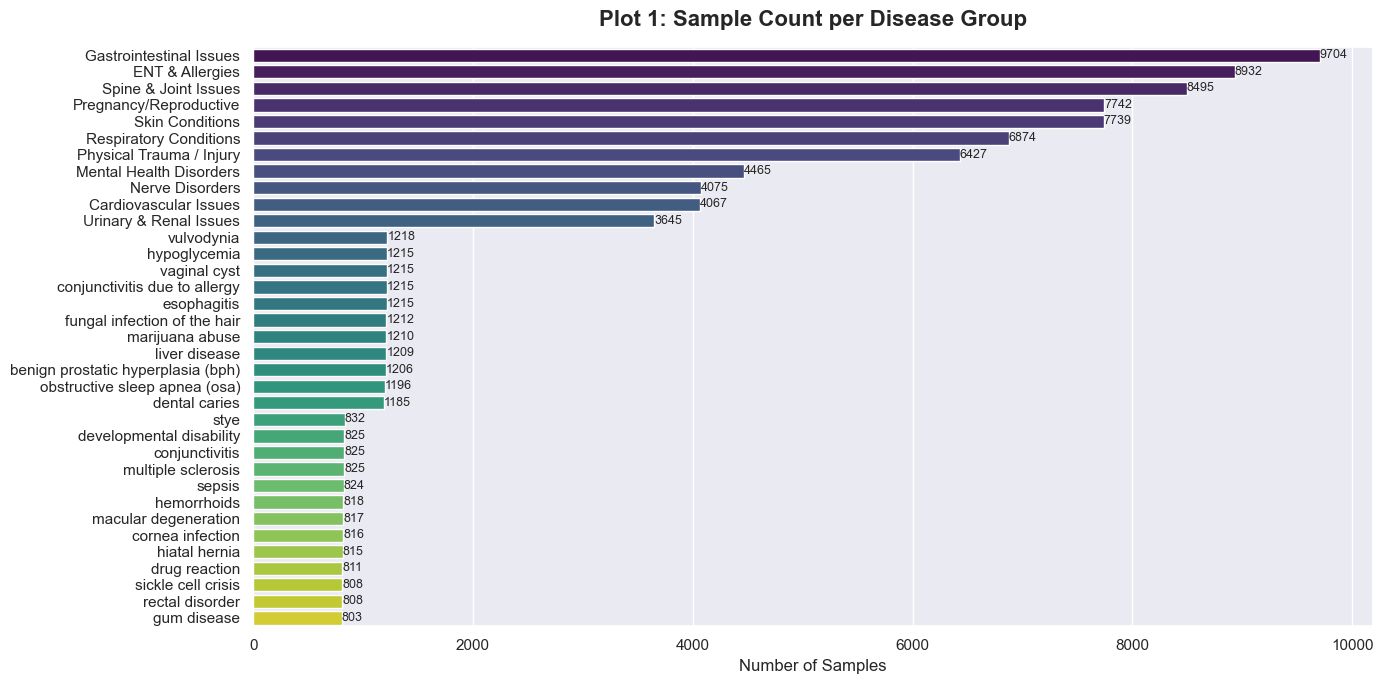

In [21]:
# ── PLOT 1: Class Distribution ────────────────────────────────
class_counts = df_plot["disease_name"].value_counts().reset_index()
class_counts.columns = ["Disease Group", "Count"]

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(data=class_counts, x="Count", y="Disease Group",
            palette="viridis", ax=ax, orient="h")
ax.set_title("Plot 1: Sample Count per Disease Group",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Number of Samples", fontsize=12)
ax.set_ylabel("")
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}",
                (p.get_width() + 1, p.get_y() + p.get_height() / 2),
                va="center", fontsize=9)
plt.tight_layout()
plt.show()

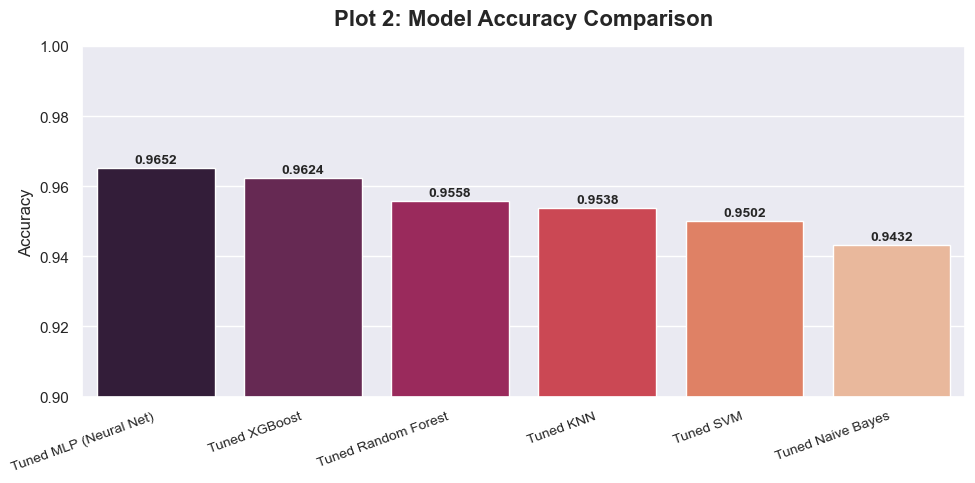

In [22]:
# ── PLOT 2: Model Accuracy Comparison ────────────────────────
results_df = pd.DataFrame(
    list(results.items()), columns=["Model", "Accuracy"]
).sort_values("Accuracy", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=results_df, x="Model", y="Accuracy",
            palette="rocket", ax=ax)
ax.set_title("Plot 2: Model Accuracy Comparison",
             fontsize=16, fontweight="bold", pad=15)
ax.set_ylim(0.90, 1.00)
ax.set_xlabel("")
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right", fontsize=10)
for p in ax.patches:
    ax.annotate(f"{p.get_height():.4f}",
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.0005),
                ha="center", va="bottom", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

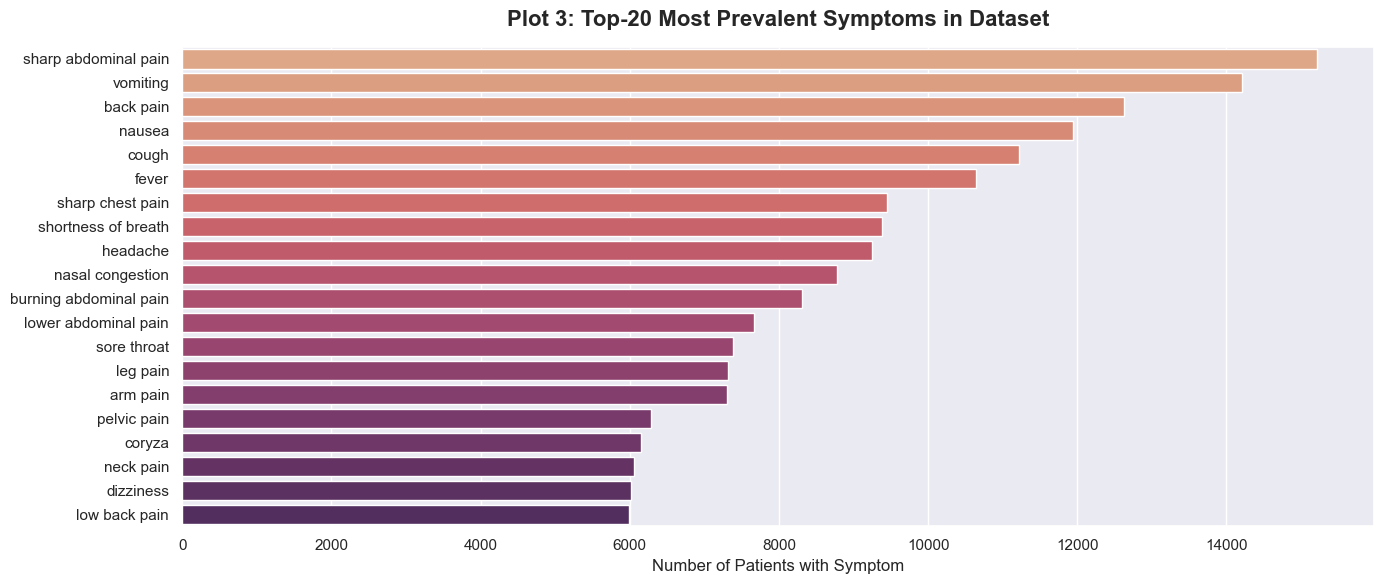

In [23]:
# ── PLOT 3: Top-20 Most Prevalent Symptoms ────────────────────
symptom_prevalence = X.sum().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(x=symptom_prevalence.values, y=symptom_prevalence.index,
            palette="flare", ax=ax, orient="h")
ax.set_title("Plot 3: Top-20 Most Prevalent Symptoms in Dataset",
             fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("Number of Patients with Symptom", fontsize=12)
ax.set_ylabel("")
plt.tight_layout()
plt.show()